# Australian Apparel Sales Analysis - Q4 2020

## Project Overview

This project analyzes fourth-quarter 2020 sales data from an Australian apparel retailer.

The objective is to clean, analyze, and visualize sales data to identify trends across:

- Geographic regions
- Customer demographic groups
- Time periods
- Sales distributions

The analysis includes data cleaning, statistical analysis, aggregation, and visualization using Python libraries including Pandas, NumPy, Matplotlib, and Seaborn.

## Tools and Libraries Used

- Python 3.11
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# 1. Environment Setup

In [1]:
import sys
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

print("Sales Analysis environment is ready!")

Sales Analysis environment is ready!


# 2. Data Loading

The dataset is loaded into a pandas DataFrame for analysis.

In [2]:
df = pd.read_csv("../data/AusApparalSales4thQrt2020.csv")

df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


# 3. Data Exploration

Initial exploration was performed to understand the dataset structure, identify missing values, detect duplicate records, and review available categories.

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("Data types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Dataset shape: (7560, 6)

Column names:
Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='str')
Data types:
Date       str
Time       str
State      str
Group      str
Unit     int64
Sales    int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


In [4]:
print("Missing values in each column:")
print(df.isna().sum())

print("\nNon-missing values in each column:")
print(df.notna().sum())

Missing values in each column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-missing values in each column:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


### Missing-Value Analysis

The dataset was inspected for missing values using the `isna()` and `notna()` functions.

The `isna().sum()` results showed that every column contained zero missing values. The `notna().sum()` results confirmed that all six columns contained 7,560 valid entries.

Therefore, no rows or columns need to be dropped, and no missing values need to be filled. Retaining the complete dataset prevents unnecessary loss of sales information.

In [5]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


### Duplicate Data Analysis

The dataset was inspected for duplicate records using the `duplicated()` function.

The analysis found **0 duplicate rows**, indicating that each record in the dataset is unique.

Since no duplicate records were identified, no rows were removed during the data cleaning process. The dataset is suitable for further analysis.

In [6]:
print("Unique States:")
print(df["State"].unique())

print(f"\nNumber of unique States: {df['State'].nunique()}")

print("\n" + "=" * 50)

print("\nUnique Groups:")
print(df["Group"].unique())

print(f"\nNumber of Groups: {df['Group'].nunique()}")

print("\n" + "=" * 50)

print("\nUnique Time Values:")
print(df["Time"].unique())

print(f"\nNumber of Time Values: {df['Time'].nunique()}")

Unique States:
<StringArray>
[' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS']
Length: 7, dtype: str

Number of unique States: 7


Unique Groups:
<StringArray>
[' Kids', ' Men', ' Women', ' Seniors']
Length: 4, dtype: str

Number of Groups: 4


Unique Time Values:
<StringArray>
[' Morning', ' Afternoon', ' Evening']
Length: 3, dtype: str

Number of Time Values: 3


# 4. Data Cleaning

Text fields were cleaned by removing leading and trailing whitespace to ensure consistent category values during analysis.

In [7]:
print(repr(df["State"].iloc[0]))
print(repr(df["Group"].iloc[0]))
print(repr(df["Time"].iloc[0]))

' WA'
' Kids'
' Morning'


In [8]:
df["State"] = df["State"].str.strip()
df["Group"] = df["Group"].str.strip()
df["Time"] = df["Time"].str.strip()

### Treatment of Missing Data

The dataset was inspected using the `isna()` and `notna()` functions to identify missing values.

The analysis showed that there were no missing values in any of the six columns. Since all 7,560 records contained complete information, no rows or columns were removed, and no missing values required replacement.

If missing values had been present, the treatment method would have depended on the importance of the affected column. Numeric values such as `Sales` or `Unit` could be replaced with statistical measures such as the mean or median when appropriate, while rows with excessive missing information could be removed to maintain data quality.

In [9]:
# Verify that no leading or trailing whitespace remains

whitespace_check = df[["State", "Group", "Time"]].apply(
    lambda s: s.str.contains(r"^\s|\s$", regex=True).sum()
)

print("Leading/Trailing Whitespace Check:")
print(whitespace_check)

Leading/Trailing Whitespace Check:
State    0
Group    0
Time     0
dtype: int64


In [10]:
print("Verified States:")
print(sorted(df["State"].unique()))

print("\nVerified Groups:")
print(sorted(df["Group"].unique()))

print("\nVerified Time Categories:")
print(sorted(df["Time"].unique()))

Verified States:
['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']

Verified Groups:
['Kids', 'Men', 'Seniors', 'Women']

Verified Time Categories:
['Afternoon', 'Evening', 'Morning']


### Data Cleaning Verification

After removing leading and trailing whitespace from the `State`, `Group`, and `Time` columns, the dataset was rechecked.

The verification found zero remaining whitespace issues in all three columns. The categorical values were also reviewed to confirm that only the expected states, demographic groups, and time-of-day categories were present.

The dataset is now clean and ready for normalization and analysis.

# 5. Data Normalization

Min-Max normalization was applied to Unit and Sales values to transform numeric values into a standardized range between 0 and 1.

## Data Normalization

Min-Max normalization will be applied to the `Unit` and `Sales` columns. This method rescales numeric values to a range between 0 and 1 while preserving the relative differences between observations.

In [11]:
# Apply Min-Max normalization to Unit and Sales

df["Unit_Normalized"] = (
    df["Unit"] - df["Unit"].min()
) / (df["Unit"].max() - df["Unit"].min()
)

df["Sales_Normalized"] = (
    df["Sales"] - df["Sales"].min()
) / (df["Sales"].max() - df["Sales"].min()
)

df.head()


,Date,Time,State,Group,Unit,Sales,Unit_Normalized,Sales_Normalized
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873


In [12]:
print("Unit normalization range:")
print(f"Minimum: {df['Unit_Normalized'].min()}")
print(f"Maximum: {df['Unit_Normalized'].max()}")

print("\nSales normalization range:")
print(f"Minimum: {df['Sales_Normalized'].min()}")
print(f"Maximum: {df['Sales_Normalized'].max()}")

Unit normalization range:
Minimum: 0.0
Maximum: 1.0

Sales normalization range:
Minimum: 0.0
Maximum: 1.0


In [13]:
# Compare original values with normilzed values

df[
    [
        "Unit",
        "Unit_Normalized",
        "Sales",
        "Sales_Normalized"
    ]
].head(10)

,Unit,Unit_Normalized,Sales,Sales_Normalized
0,8,0.095238,20000,0.095238
1,8,0.095238,20000,0.095238
2,4,0.031746,10000,0.031746
3,15,0.206349,37500,0.206349
4,3,0.015873,7500,0.015873
5,10,0.126984,25000,0.126984
6,3,0.015873,7500,0.015873
7,11,0.142857,27500,0.142857
8,15,0.206349,37500,0.206349
9,15,0.206349,37500,0.206349


### Normalization Observation

The normalized `Unit` and `Sales` values are identical for each observation. This occurs because the original `Sales` values maintain a constant proportional relationship with `Unit`.

For the displayed records, sales are calculated as approximately `Unit × 2,500`. Since Min-Max normalization preserves relative position within a column, multiplying every value by the same constant does not change the normalized result.

The normalization was therefore performed correctly.

# 6. Statistical Analysis

Descriptive statistics were calculated to understand sales distribution, central tendency, and variability.

In [14]:
# Display descriptive statistics for the numeric columns

df[["Unit", "Sales"]].describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [15]:
print("Unit Statistics")
print(f"Mean: {df['Unit'].mean()}")
print(f"Median: {df['Unit'].median()}")
print(f"Mode: {df['Unit'].mode().tolist()}")
print(f"Standard Deviation: {df['Unit'].std()}")

print("\n" + "=" * 50 + "\n")

print("Sales Statistics")
print(f"Mean: {df['Sales'].mean()}")
print(f"Median: {df['Sales'].median()}")
print(f"Mode: {df['Sales'].mode().tolist()}")
print(f"Standard Deviation: {df['Sales'].std()}")


Unit Statistics
Mean: 18.00542328042328
Median: 14.0
Mode: [9]
Standard Deviation: 12.90140277758643


Sales Statistics
Mean: 45013.5582010582
Median: 35000.0
Mode: [22500]
Standard Deviation: 32253.506943966073


### Descriptive Statistics

The `mean()`, `median()`, `mode()`, and `std()` functions were used to summarize the numeric columns.

For the `Unit` column:
- The average number of units sold was approximately **18**.
- The median number of units sold was **14**.
- The most frequently occurring value (mode) was **9**.
- The standard deviation was approximately **12.90**, indicating noticeable variation in units sold.

For the `Sales` column:
- The average sales amount was approximately **45,014**.
- The median sales amount was **35,000**.
- The most common sales amount was **22,500**.
- The standard deviation was approximately **32,253**, indicating considerable variation in sales values.

In [16]:
state_sales = df.groupby("State")["Sales"].sum()

state_sales

State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64

In [17]:
print(f"State with the highest sales: {state_sales.idxmax()}")
print(f"Highest sales amount: {state_sales.max():,}")

print()

print(f"State with the lowest sales: {state_sales.idxmin()}")
print(f"Lowest sales amount: {state_sales.min():,}")

State with the highest sales: VIC
Highest sales amount: 105,565,000

State with the lowest sales: WA
Lowest sales amount: 22,152,500


# 7. Sales Analysis

Sales performance was analyzed across geographic regions, demographic groups, and purchasing behavior.

### Sales by State Analysis

The dataset was grouped by the `State` column using the `groupby()` function, and the total sales for each state were calculated using the `sum()` function.

The analysis showed that:

- **Victoria (VIC)** recorded the highest total sales with **105,565,000**.
- **Western Australia (WA)** recorded the lowest total sales with **22,152,500**.

Grouping the data by state provides insight into regional sales performance and helps identify the strongest and weakest performing markets.

In [18]:
# Sort states by total sales (highest to lowest)

state_sales_sorted = state_sales.sort_values(ascending=False)

state_sales_sorted

State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

# Australian Apparel Sales Analysis - Q4 2020

## Project Overview

This project analyzes fourth-quarter 2020 sales data from an Australian apparel retailer.

The objective is to clean, analyze, and visualize sales data to identify trends across:

- Geographic regions
- Customer demographic groups
- Time periods
- Sales distributions

The analysis includes data cleaning, statistical analysis, aggregation, and visualization using Python libraries including Pandas, NumPy, Matplotlib, and Seaborn.

## Tools and Libraries Used

- Python 3.11
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# 1. Environment Setup

In [ ]:
import sys
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

print("Sales Analysis environment is ready!")

Sales Analysis environment is ready!


# 2. Data Loading

The dataset is loaded into a pandas DataFrame for analysis.

In [ ]:
df = pd.read_csv("../data/AusApparalSales4thQrt2020.csv")

df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


# 3. Data Exploration

Initial exploration was performed to understand the dataset structure, identify missing values, detect duplicate records, and review available categories.

In [ ]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns)

print("Data types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Dataset shape: (7560, 6)

Column names:
Index(['Date', 'Time', 'State', 'Group', 'Unit', 'Sales'], dtype='str')
Data types:
Date       str
Time       str
State      str
Group      str
Unit     int64
Sales    int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


In [ ]:
print("Missing values in each column:")
print(df.isna().sum())

print("\nNon-missing values in each column:")
print(df.notna().sum())

Missing values in each column:
Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-missing values in each column:
Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


### Missing-Value Analysis

The dataset was inspected for missing values using the `isna()` and `notna()` functions.

The `isna().sum()` results showed that every column contained zero missing values. The `notna().sum()` results confirmed that all six columns contained 7,560 valid entries.

Therefore, no rows or columns need to be dropped, and no missing values need to be filled. Retaining the complete dataset prevents unnecessary loss of sales information.

In [ ]:
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


### Duplicate Data Analysis

The dataset was inspected for duplicate records using the `duplicated()` function.

The analysis found **0 duplicate rows**, indicating that each record in the dataset is unique.

Since no duplicate records were identified, no rows were removed during the data cleaning process. The dataset is suitable for further analysis.

In [ ]:
print("Unique States:")
print(df["State"].unique())

print(f"\nNumber of unique States: {df['State'].nunique()}")

print("\n" + "=" * 50)

print("\nUnique Groups:")
print(df["Group"].unique())

print(f"\nNumber of Groups: {df['Group'].nunique()}")

print("\n" + "=" * 50)

print("\nUnique Time Values:")
print(df["Time"].unique())

print(f"\nNumber of Time Values: {df['Time'].nunique()}")

Unique States:
<StringArray>
[' WA', ' NT', ' SA', ' VIC', ' QLD', ' NSW', ' TAS']
Length: 7, dtype: str

Number of unique States: 7


Unique Groups:
<StringArray>
[' Kids', ' Men', ' Women', ' Seniors']
Length: 4, dtype: str

Number of Groups: 4


Unique Time Values:
<StringArray>
[' Morning', ' Afternoon', ' Evening']
Length: 3, dtype: str

Number of Time Values: 3


# 4. Data Cleaning

Text fields were cleaned by removing leading and trailing whitespace to ensure consistent category values during analysis.

In [ ]:
print(repr(df["State"].iloc[0]))
print(repr(df["Group"].iloc[0]))
print(repr(df["Time"].iloc[0]))

' WA'
' Kids'
' Morning'


In [ ]:
df["State"] = df["State"].str.strip()
df["Group"] = df["Group"].str.strip()
df["Time"] = df["Time"].str.strip()

### Treatment of Missing Data

The dataset was inspected using the `isna()` and `notna()` functions to identify missing values.

The analysis showed that there were no missing values in any of the six columns. Since all 7,560 records contained complete information, no rows or columns were removed, and no missing values required replacement.

If missing values had been present, the treatment method would have depended on the importance of the affected column. Numeric values such as `Sales` or `Unit` could be replaced with statistical measures such as the mean or median when appropriate, while rows with excessive missing information could be removed to maintain data quality.

In [ ]:
# Verify that no leading or trailing whitespace remains

whitespace_check = df[["State", "Group", "Time"]].apply(
    lambda s: s.str.contains(r"^\s|\s$", regex=True).sum()
)

print("Leading/Trailing Whitespace Check:")
print(whitespace_check)

Leading/Trailing Whitespace Check:
State    0
Group    0
Time     0
dtype: int64


In [ ]:
print("Verified States:")
print(sorted(df["State"].unique()))

print("\nVerified Groups:")
print(sorted(df["Group"].unique()))

print("\nVerified Time Categories:")
print(sorted(df["Time"].unique()))

Verified States:
['NSW', 'NT', 'QLD', 'SA', 'TAS', 'VIC', 'WA']

Verified Groups:
['Kids', 'Men', 'Seniors', 'Women']

Verified Time Categories:
['Afternoon', 'Evening', 'Morning']


### Data Cleaning Verification

After removing leading and trailing whitespace from the `State`, `Group`, and `Time` columns, the dataset was rechecked.

The verification found zero remaining whitespace issues in all three columns. The categorical values were also reviewed to confirm that only the expected states, demographic groups, and time-of-day categories were present.

The dataset is now clean and ready for normalization and analysis.

# 5. Data Normalization

Min-Max normalization was applied to Unit and Sales values to transform numeric values into a standardized range between 0 and 1.

## Data Normalization

Min-Max normalization will be applied to the `Unit` and `Sales` columns. This method rescales numeric values to a range between 0 and 1 while preserving the relative differences between observations.

In [ ]:
# Apply Min-Max normalization to Unit and Sales

df["Unit_Normalized"] = (
    df["Unit"] - df["Unit"].min()
) / (df["Unit"].max() - df["Unit"].min()
)

df["Sales_Normalized"] = (
    df["Sales"] - df["Sales"].min()
) / (df["Sales"].max() - df["Sales"].min()
)

df.head()


,Date,Time,State,Group,Unit,Sales,Unit_Normalized,Sales_Normalized
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873,0.015873


In [ ]:
print("Unit normalization range:")
print(f"Minimum: {df['Unit_Normalized'].min()}")
print(f"Maximum: {df['Unit_Normalized'].max()}")

print("\nSales normalization range:")
print(f"Minimum: {df['Sales_Normalized'].min()}")
print(f"Maximum: {df['Sales_Normalized'].max()}")

Unit normalization range:
Minimum: 0.0
Maximum: 1.0

Sales normalization range:
Minimum: 0.0
Maximum: 1.0


In [ ]:
# Compare original values with normilzed values

df[
    [
        "Unit",
        "Unit_Normalized",
        "Sales",
        "Sales_Normalized"
    ]
].head(10)

,Unit,Unit_Normalized,Sales,Sales_Normalized
0,8,0.095238,20000,0.095238
1,8,0.095238,20000,0.095238
2,4,0.031746,10000,0.031746
3,15,0.206349,37500,0.206349
4,3,0.015873,7500,0.015873
5,10,0.126984,25000,0.126984
6,3,0.015873,7500,0.015873
7,11,0.142857,27500,0.142857
8,15,0.206349,37500,0.206349
9,15,0.206349,37500,0.206349


### Normalization Observation

The normalized `Unit` and `Sales` values are identical for each observation. This occurs because the original `Sales` values maintain a constant proportional relationship with `Unit`.

For the displayed records, sales are calculated as approximately `Unit × 2,500`. Since Min-Max normalization preserves relative position within a column, multiplying every value by the same constant does not change the normalized result.

The normalization was therefore performed correctly.

# 6. Statistical Analysis

Descriptive statistics were calculated to understand sales distribution, central tendency, and variability.

In [ ]:
# Display descriptive statistics for the numeric columns

df[["Unit", "Sales"]].describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [ ]:
print("Unit Statistics")
print(f"Mean: {df['Unit'].mean()}")
print(f"Median: {df['Unit'].median()}")
print(f"Mode: {df['Unit'].mode().tolist()}")
print(f"Standard Deviation: {df['Unit'].std()}")

print("\n" + "=" * 50 + "\n")

print("Sales Statistics")
print(f"Mean: {df['Sales'].mean()}")
print(f"Median: {df['Sales'].median()}")
print(f"Mode: {df['Sales'].mode().tolist()}")
print(f"Standard Deviation: {df['Sales'].std()}")


Unit Statistics
Mean: 18.00542328042328
Median: 14.0
Mode: [9]
Standard Deviation: 12.90140277758643


Sales Statistics
Mean: 45013.5582010582
Median: 35000.0
Mode: [22500]
Standard Deviation: 32253.506943966073


### Descriptive Statistics

The `mean()`, `median()`, `mode()`, and `std()` functions were used to summarize the numeric columns.

For the `Unit` column:
- The average number of units sold was approximately **18**.
- The median number of units sold was **14**.
- The most frequently occurring value (mode) was **9**.
- The standard deviation was approximately **12.90**, indicating noticeable variation in units sold.

For the `Sales` column:
- The average sales amount was approximately **45,014**.
- The median sales amount was **35,000**.
- The most common sales amount was **22,500**.
- The standard deviation was approximately **32,253**, indicating considerable variation in sales values.

In [ ]:
state_sales = df.groupby("State")["Sales"].sum()

state_sales

State
NSW     74970000
NT      22580000
QLD     33417500
SA      58857500
TAS     22760000
VIC    105565000
WA      22152500
Name: Sales, dtype: int64

In [ ]:
print(f"State with the highest sales: {state_sales.idxmax()}")
print(f"Highest sales amount: {state_sales.max():,}")

print()

print(f"State with the lowest sales: {state_sales.idxmin()}")
print(f"Lowest sales amount: {state_sales.min():,}")

State with the highest sales: VIC
Highest sales amount: 105,565,000

State with the lowest sales: WA
Lowest sales amount: 22,152,500


# 7. Sales Analysis

Sales performance was analyzed across geographic regions, demographic groups, and purchasing behavior.

### Sales by State Analysis

The dataset was grouped by the `State` column using the `groupby()` function, and the total sales for each state were calculated using the `sum()` function.

The analysis showed that:

- **Victoria (VIC)** recorded the highest total sales with **105,565,000**.
- **Western Australia (WA)** recorded the lowest total sales with **22,152,500**.

Grouping the data by state provides insight into regional sales performance and helps identify the strongest and weakest performing markets.

In [ ]:
# Sort states by total sales (highest to lowest)

state_sales_sorted = state_sales.sort_values(ascending=False)

state_sales_sorted

State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

In [ ]:
group_sales = df.groupby("Group")["Sales"].sum()

group_sales_sorted = group_sales.sort_values(ascending=False)
group_sales_sorted

Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

In [ ]:
print(f"Group with the highest sales: {group_sales.idxmax()}")
print(f"Highest groups sales amount: {group_sales.max():,}")

print()

print(f"Group with the lowest sales: {group_sales.idxmin()}")
print(f"Lowest groups sales amount: {group_sales.min():,}")

Group with the highest sales: Men
Highest groups sales amount: 85,750,000

Group with the lowest sales: Seniors
Lowest groups sales amount: 84,037,500


### Sales by Demographic Group

The dataset was grouped by the `Group` column, and total sales were calculated for each demographic group.

The analysis showed that:

- **Men** generated the highest total sales at **85,750,000**.
- **Women** generated **85,442,500** in total sales.
- **Kids** generated **85,072,500** in total sales.
- **Seniors** generated the lowest total sales at **84,037,500**.

Although Men recorded the highest sales and Seniors recorded the lowest sales, total sales were relatively similar across all four demographic groups.

In [ ]:
group_units = df.groupby("Group")["Unit"].sum()

group_units_sorted = group_units.sort_values(ascending=False)
group_units_sorted

Group
Men        34300
Women      34177
Kids       34029
Seniors    33615
Name: Unit, dtype: int64

In [ ]:
print(f"Group with the highest units sold: {group_units.idxmax()}")
print(f"Highest units sold amount: {group_units.max():,}")

print()

print(f"Group with the lowest units sold: {group_units.idxmin()}")
print(f"Lowest units sold amount: {group_units.min():,}")

Group with the highest units sold: Men
Highest units sold amount: 34,300

Group with the lowest units sold: Seniors
Lowest units sold amount: 33,615


### Units Sold by Demographic Group

The dataset was grouped by the `Group` column, and the total number of units sold was calculated for each demographic group.

The analysis showed that:

- **Men** purchased the highest number of units at **34,300**.
- **Women** purchased **34,177** units.
- **Kids** purchased **34,029** units.
- **Seniors** purchased the lowest number of units at **33,615**.

The unit results follow the same pattern as the sales results. Men generated both the highest number of units sold and the highest total sales, while Seniors generated the lowest number of units sold and the lowest total sales.

# 8. Time-Based Sales Analysis

Sales trends were analyzed over weekly, monthly, and quarterly periods.

In [ ]:
# Convert Date column from string format to datetime format
df["Date"] = pd.to_datetime(df["Date"])

print("Date data type:")
print(df["Date"].dtype)

print("\nFirst five dates:")
print(df["Date"].head())


pd.to_datetime

Date data type:
datetime64[us]

First five dates:
0   2020-10-01
1   2020-10-01
2   2020-10-01
3   2020-10-01
4   2020-10-01
Name: Date, dtype: datetime64[us]


<function pandas.to_datetime(arg: 'DatetimeScalarOrArrayConvertible | DictConvertible', errors: 'DateTimeErrorChoices' = 'raise', dayfirst: 'bool' = False, yearfirst: 'bool' = False, utc: 'bool' = False, format: 'str | None' = None, exact: 'bool | lib.NoDefault' = <no_default>, unit: 'str | None' = None, origin: 'str' = 'unix', cache: 'bool' = True) -> 'DatetimeIndex | Series | DatetimeScalar | NaTType'>

In [ ]:
# Calculate total sales by week
weekly_sales = (
    df.groupby(pd.Grouper(key="Date", freq="W"))["Sales"].sum()
)

weekly_sales

Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

In [ ]:
weekly_sales_formatted = weekly_sales.to_frame(name="Total Sales")

weekly_sales_formatted["Total Sales"] = (
    weekly_sales_formatted["Total Sales"].map("${:,.0f}".format)
)

weekly_sales_formatted

,Total Sales
Date,
2020-10-04,"$15,045,000"
2020-10-11,"$27,002,500"
2020-10-18,"$26,640,000"
2020-10-25,"$26,815,000"
2020-11-01,"$21,807,500"
2020-11-08,"$20,865,000"
2020-11-15,"$21,172,500"
2020-11-22,"$21,112,500"
2020-11-29,"$21,477,500"


### Weekly Sales Report

Sales were grouped into weekly periods using the `Date` column. Each weekly period is labeled using the Sunday on which the week ends.

The weekly analysis shows variation in sales throughout the quarter, with stronger weekly sales occurring during December. The final weekly period is labeled January 3, 2021 because the last days of December fall within a week ending on that date; the underlying sales records remain part of the fourth quarter of 2020.

In [ ]:
# Calculate total sales by month
monthly_sales = (
    df.groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].sum()
)

monthly_sales

Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

In [ ]:
monthly_sales_formatted = monthly_sales.to_frame(name="Total Sales")

monthly_sales_formatted["Total Sales"] = (
    monthly_sales_formatted["Total Sales"].map("${:,.0f}".format)
)

monthly_sales_formatted

,Total Sales
Date,
2020-10-31,"$114,290,000"
2020-11-30,"$90,682,500"
2020-12-31,"$135,330,000"


### Monthly Sales Report

Sales were grouped by month using the `Date` column.

The results showed:

- **October 2020:** $114,290,000
- **November 2020:** $90,682,500
- **December 2020:** $135,330,000

December generated the highest monthly sales, while November generated the lowest. The results indicate a decline in sales during November followed by a strong increase in December.

### Quarterly Sales Report

Sales were grouped by quarter using the `Date` column.

For the fourth quarter of 2020, total sales were **$340,302,500**.

The quarterly total is consistent with the combined monthly sales from October, November, and December. This confirms that the time-based aggregation was performed correctly.

In [54]:
# Calculate total sales for Q4 2020
quarterly_sales = (
    df.groupby(pd.Grouper(key="Date", freq="QE"))["Sales"].sum()
)

quarterly_sales

Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64

In [55]:
quarterly_sales_formatted = quarterly_sales.to_frame(name="Total Sales")

quarterly_sales_formatted["Total Sales"] = (
    quarterly_sales_formatted["Total Sales"].map("${:,.0f}".format)
)

quarterly_sales_formatted

,Total Sales
Date,
2020-12-31,"$340,302,500"


## Quarterly Sales Visualization

The quarterly chart summarizes total sales performance for Q4 2020.

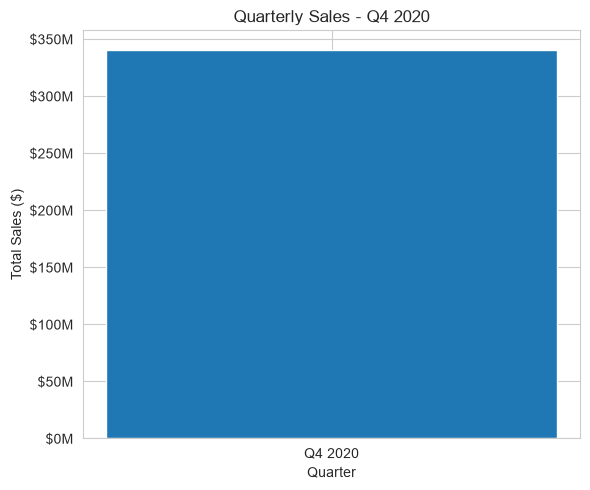

In [57]:
# Visualize quarterly sales

plt.figure(figsize=(6, 5))

plt.bar(
    ["Q4 2020"],
    [quarterly_sales.iloc[0]]
)

plt.title("Quarterly Sales - Q4 2020")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

# 9. Data Visualization

Visualizations were created to identify sales patterns across states, demographic groups, time periods, and sales distributions.

# Data Visualization

Visualizations were created to identify sales patterns across states, demographic groups, and time periods. The charts provide a graphical representation of the findings obtained during the data analysis.

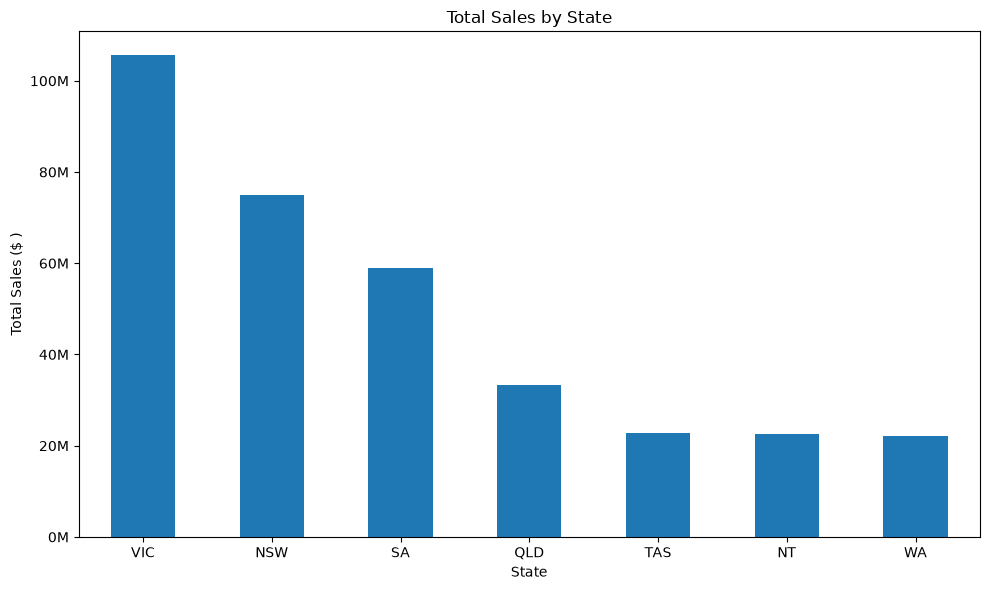

In [ ]:
# Visualize total sales by state

plt.figure(figsize=(10, 6))

state_sales_sorted.plot(kind="bar")

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales ($ )")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### State-Wise Sales Analysis

The state-wise sales visualization shows substantial differences in sales performance across the Australian states represented in the dataset.

**Victoria (VIC)** generated the highest total sales at **$105.565 million**, followed by **New South Wales (NSW)** at **$74.970 million** and **South Australia (SA)** at **$58.858 million**.

**Western Australia (WA)** recorded the lowest total sales at **$22.153 million**. Tasmania (TAS) and the Northern Territory (NT) also recorded substantially lower sales than the three highest-performing states.

The visualization demonstrates that Victoria was the strongest-performing state during the fourth quarter of 2020.

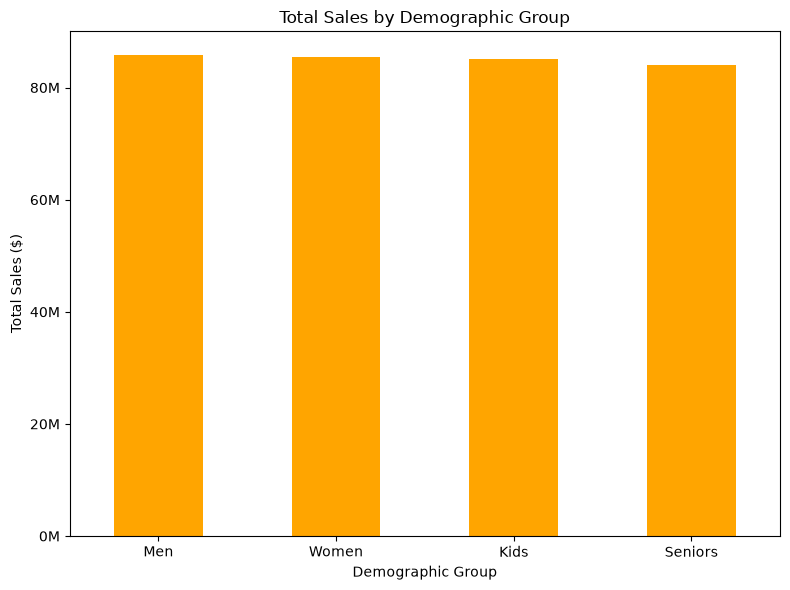

In [ ]:
# Visualize total sales by demographic group

plt.figure(figsize=(8, 6))

group_sales_sorted.plot(kind="bar", color="orange")

plt.title("Total Sales by Demographic Group")
plt.xlabel("Demographic Group")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Group-Wise Sales Analysis

The group-wise sales visualization shows that total sales were relatively consistent across all four demographic groups.

**Men** generated the highest total sales at **$85.750 million**, followed closely by **Women** at **$85.443 million** and **Kids** at **$85.073 million**. **Seniors** generated the lowest total sales at **$84.038 million**.

Although Men recorded the highest sales and Seniors recorded the lowest, the differences between the demographic groups were relatively small. This suggests that sales were distributed fairly evenly across the four customer groups during the fourth quarter of 2020.

In [ ]:
time_sales = df.groupby("Time")["Sales"].sum()

time_sales_sorted = time_sales.sort_values(ascending=False)

time_sales_sorted

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64

In [ ]:
print("Time with the highest sales:", time_sales_sorted.idxmax())
print(f"Highest time sales amount: ${time_sales_sorted.max():,}")

print()

print(f"Time with the lowest sales: {time_sales_sorted.idxmin()}")
print(f"Lowest time sales amount: ${time_sales_sorted.min():,}")



Time with the highest sales: Morning
Highest time sales amount: $114,207,500

Time with the lowest sales: Evening
Lowest time sales amount: $112,087,500


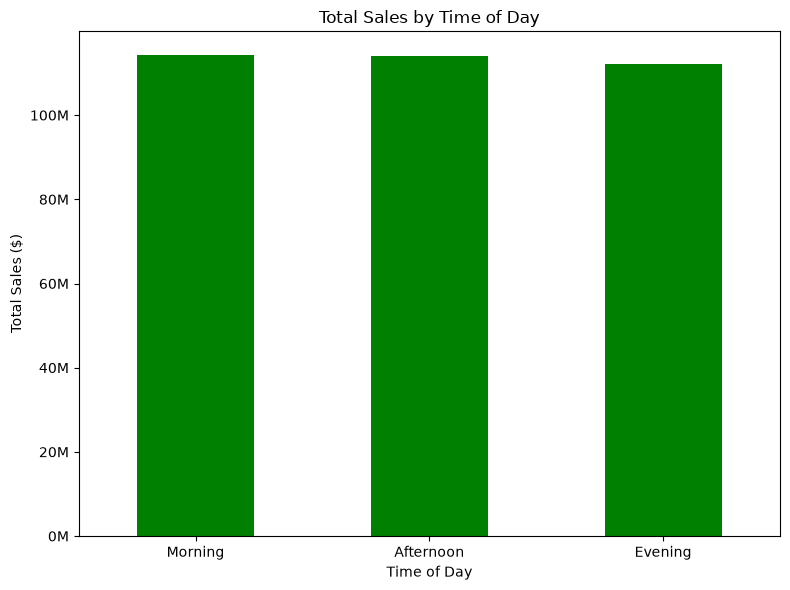

In [ ]:
# Visualize sales by time of day

plt.figure(figsize=(8, 6))

time_sales_sorted.plot(kind="bar", color="green")

plt.title("Total Sales by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Time-of-Day Sales Analysis

The time-of-day analysis shows that sales were relatively consistent throughout the day.

- **Morning** generated the highest total sales at **$114,207,500**.
- **Afternoon** generated **$114,007,500**.
- **Evening** generated the lowest total sales at **$112,087,500**.

Morning and afternoon sales were particularly similar, with only a small difference between the two periods. Although evening sales were slightly lower, the results do not indicate a major difference in sales performance based solely on time of day.

From a marketing perspective, morning and afternoon may provide slightly stronger opportunities for customer engagement. However, because sales were relatively balanced across all three periods, the data does not support concentrating marketing efforts exclusively on a single time of day.

## Sales Distribution Analysis

A distribution plot was created to examine the frequency and spread of individual sales values throughout the dataset.

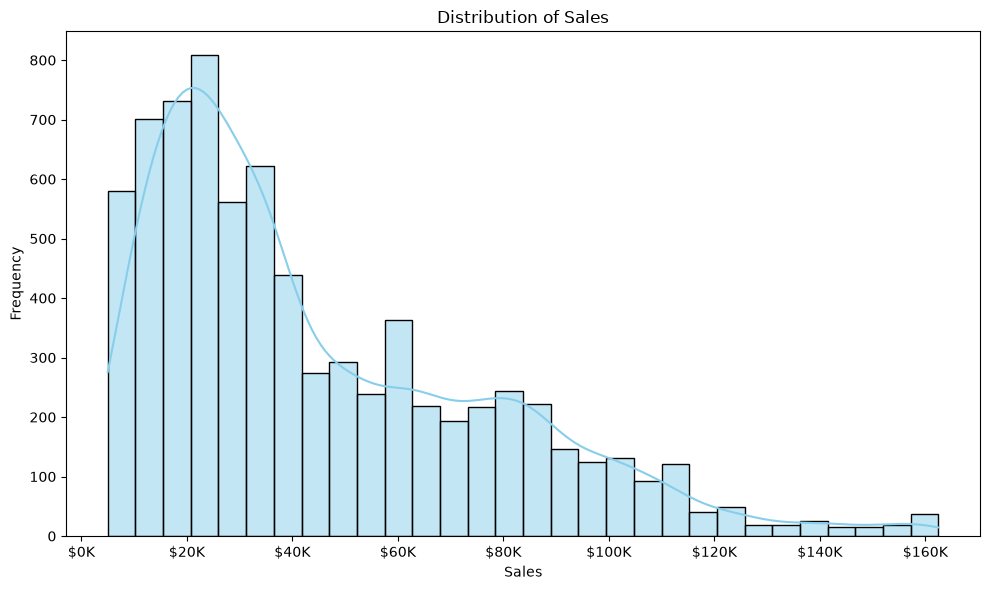

In [ ]:
# Analyze sales distribution

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True,
    color="skyblue"
    )

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Sales Distribution Findings

The sales distribution is right-skewed (positively skewed), with a large concentration of observations at lower sales values and a progressively smaller number of observations at higher sales values.

The distribution helps explain why the **mean sales value of approximately $45,014** is higher than the **median sales value of $35,000**. Higher-value sales observations extend the right tail of the distribution and pull the mean upward.

The distribution therefore indicates that lower-to-moderate sales values occur more frequently, while very high sales values occur less frequently.

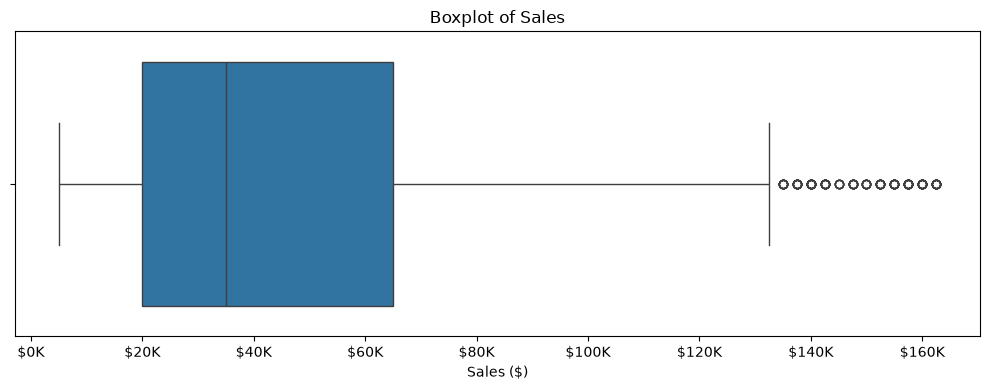

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Sales"
    )

plt.title("Boxplot of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Box Plot Analysis

The box plot provides a visual summary of the distribution and spread of sales values.

The middle 50% of sales observations fall between approximately **$20,000 (Q1)** and **$65,000 (Q3)**, with a median sales value of **$35,000**.

Several high-value observations appear above the upper whisker and are identified as potential outliers by the box plot. These observations extend to a maximum sales value of **$162,500**. These values were retained because there is no evidence that they represent incorrect or invalid data.

The longer upper range and high-value observations further support the finding that the sales distribution is right-skewed.

# Daily Sales and Peak/Off-peak Analysis

The following cells add a daily sales chart (line plot) and a concise peak/off-peak analysis by time-of-day. These visualizations use Seaborn for consistent styling and clear statistical plots.

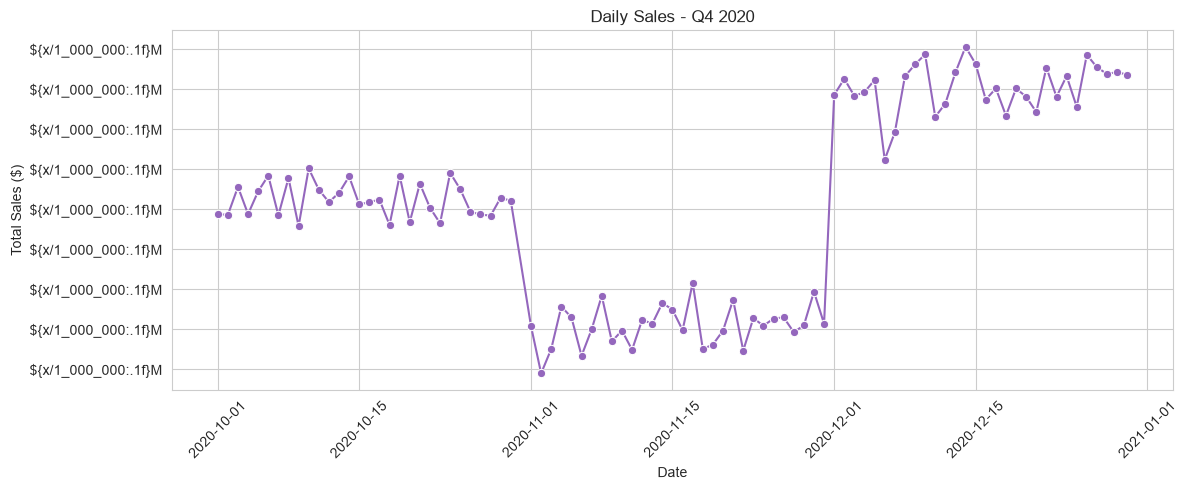

In [49]:
# Daily sales aggregation and line chart
daily_sales = df.groupby(df['Date'].dt.date)['Sales'].sum()
daily_sales.index = pd.to_datetime(daily_sales.index)

plt.figure(figsize=(12, 5))
sns.set_style('whitegrid')
sns.lineplot(x=daily_sales.index, y=daily_sales.values, marker='o', color='tab:purple')
plt.title('Daily Sales - Q4 2020')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${{x/1_000_000:.1f}}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Keep the daily_sales series available for downstream reporting
daily_sales = daily_sales

Time-of-day sales (total and % contribution):
               Sales        Pct
Time                           
Afternoon  114007500  33.501811
Evening    112087500  32.937607
Morning    114207500  33.560582

Peak period: Morning (114,207,500 | 33.6% )
Off-peak period: Evening (112,087,500 | 32.9% )


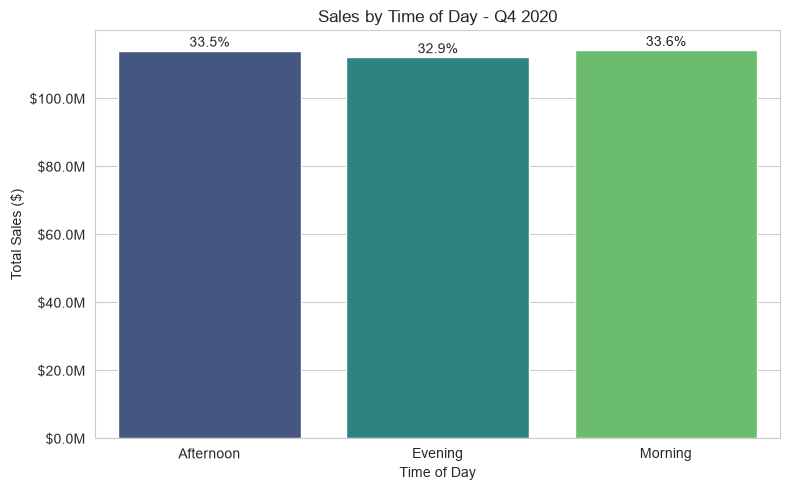

In [50]:
# Peak / Off-peak analysis using existing time-of-day grouping

# Percent contribution by period
time_sales_pct = (time_sales / time_sales.sum()) * 100

print('Time-of-day sales (total and % contribution):')
print(pd.concat([time_sales, time_sales_pct.rename('Pct')], axis=1))

peak = time_sales.idxmax()
offpeak = time_sales.idxmin()
print()
print(f'Peak period: {peak} ({time_sales[peak]:,} | {time_sales_pct[peak]:.1f}% )')
print(f'Off-peak period: {offpeak} ({time_sales[offpeak]:,} | {time_sales_pct[offpeak]:.1f}% )')

# Visualize with Seaborn barplot and annotate percentages
plt.figure(figsize=(8, 5))
sns.barplot(x=time_sales.index, y=time_sales.values, hue=time_sales.index, palette='viridis', legend=False)
plt.title('Sales by Time of Day - Q4 2020')
plt.xlabel('Time of Day')
plt.ylabel('Total Sales ($)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M"))
for i, v in enumerate(time_sales.values):
    pct = time_sales_pct.iloc[i]
    plt.text(i, v + max(time_sales.values)*0.01, f"{pct:.1f}%", ha='center')
plt.tight_layout()
plt.show()

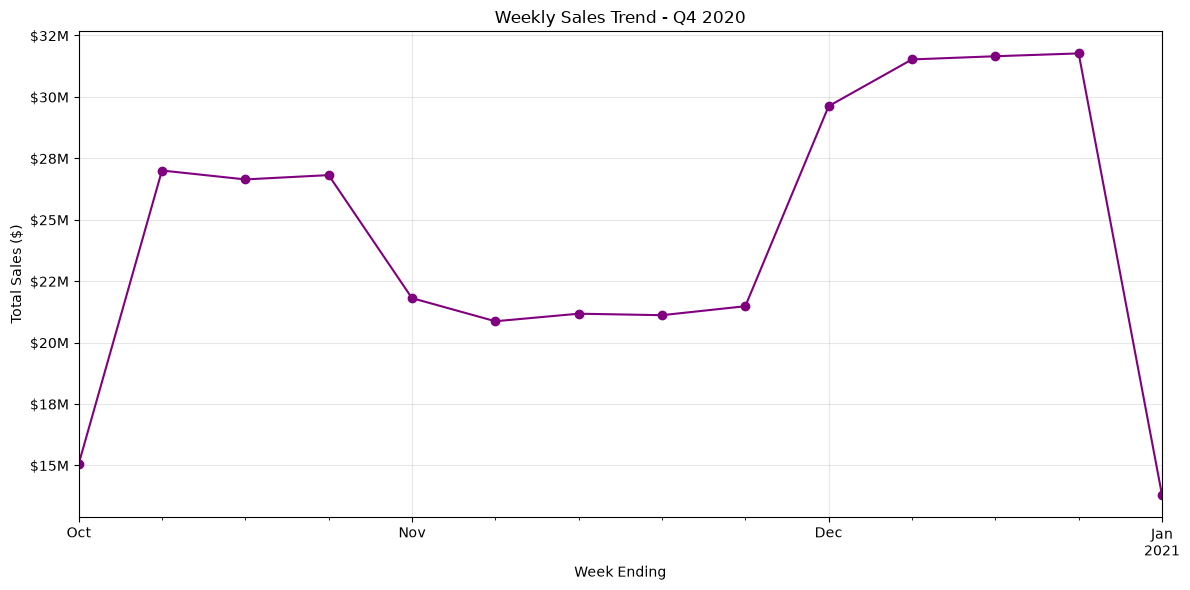

In [ ]:
# Visualize weekly sales trends

plt.figure(figsize=(12, 6))

weekly_sales.plot(kind="line",
                  marker="o",
                  color="purple"
                  )

plt.title("Weekly Sales Trend - Q4 2020")
plt.xlabel("Week Ending")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.grid(True, alpha=0.3)  # Add grid lines with some transparency
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()



### Weekly Sales Trend Analysis

The weekly sales trend shows noticeable changes in sales performance throughout the fourth quarter of 2020.

Sales remained relatively strong during most of October before declining during November. Weekly sales generally remained around $21 million during much of November.

A significant increase occurred beginning in late November and continued throughout December. Weekly sales exceeded approximately $29 million at the beginning of December and remained above $31 million during several weeks later in the month.

The first and final data points represent partial weeks because the dataset begins on October 1 and ends on December 31. Therefore, their lower sales totals should not be interpreted as full-week performance.

Overall, the weekly trend supports the monthly analysis, showing weaker sales performance during November followed by substantial growth during December.

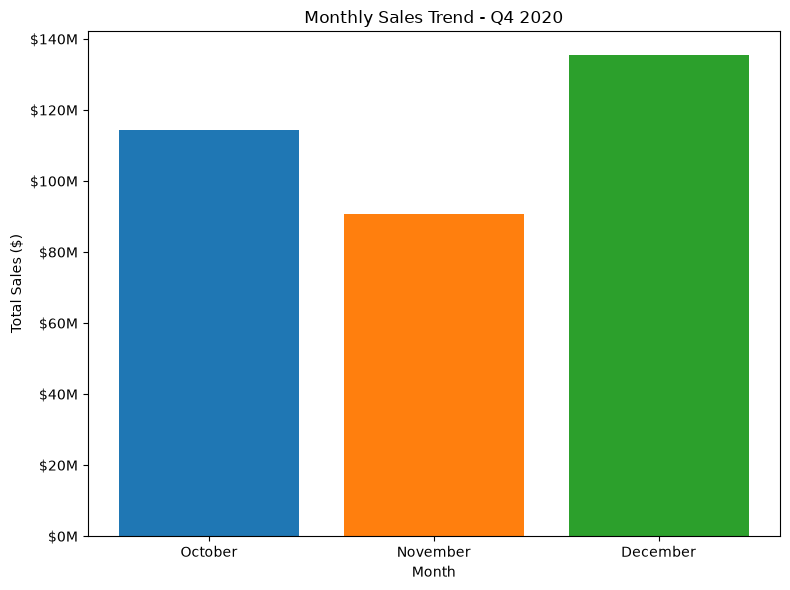

In [ ]:
plt.figure(figsize=(8, 6))

plt.bar(
    ["October", "November", "December"],
    monthly_sales.to_list(),
    color=["#1f77b4", "#ff7f0e", "#2ca02c"]  # Different colors for each month
)

plt.title("Monthly Sales Trend - Q4 2020")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.tight_layout()
plt.show()

### Monthly Sales Trend Analysis

The monthly sales analysis shows a clear change in sales performance during the fourth quarter of 2020.

- **October** generated approximately **$114.29 million** in sales.
- **November** declined to approximately **$90.68 million**, making it the lowest-performing month of the quarter.
- **December** increased significantly to approximately **$135.33 million**, making it the strongest-performing month.

The results indicate a decline in sales during November followed by a strong recovery in December. This trend is consistent with the weekly sales analysis, which also showed stronger sales performance toward the end of the quarter.

In [ ]:
state_group_sales = df.groupby(["State", "Group"])["Sales"].sum().unstack()

print(state_group_sales)

Group      Kids       Men   Seniors     Women
State                                        
NSW    18587500  19022500  18187500  19172500
NT      5700000   5762500   5465000   5652500
QLD     8510000   8392500   8190000   8325000
SA     14515000  14655000  14717500  14970000
TAS     5775000   5757500   5650000   5577500
VIC    26360000  26407500  26315000  26482500
WA      5625000   5752500   5512500   5262500


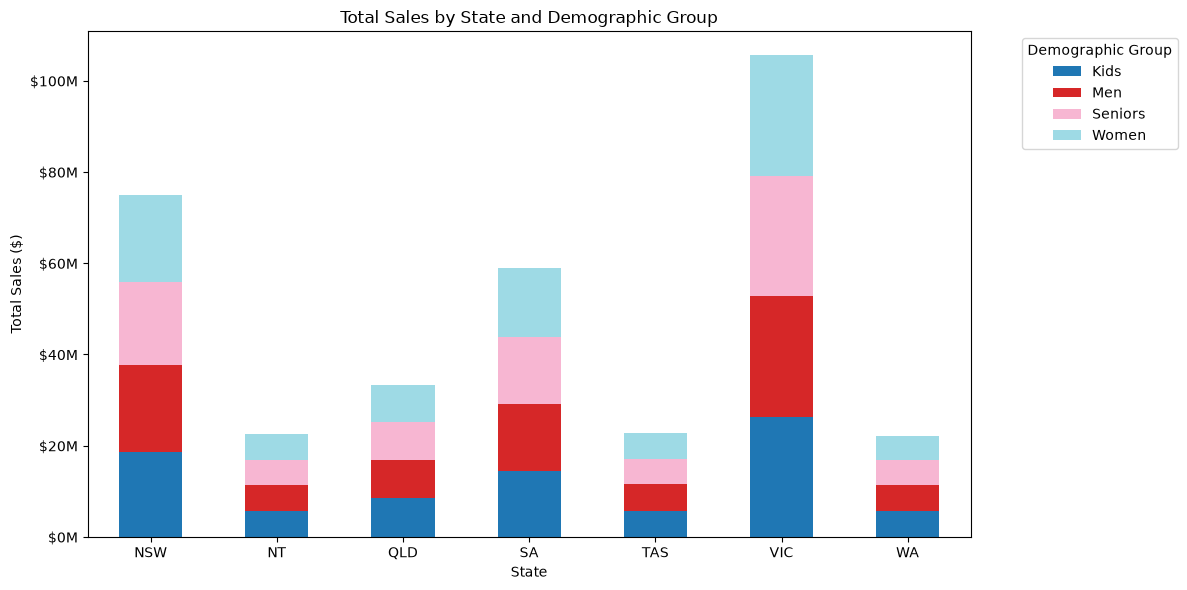

In [ ]:
# Compare demographic sales contribution by state

state_group_sales.plot(
    kind="bar",
    figsize=(12, 6),
    stacked=True,
    colormap="tab20"
)

plt.title("Total Sales by State and Demographic Group")
plt.xlabel("State")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.legend(title="Demographic Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# 10. Business Insights and Recommendations

# Business Insights and Recommendations

## Key Findings

### Regional Performance

Victoria (VIC) generated the highest total sales during Q4 2020 with approximately **$105.6 million**, making it the strongest-performing state. Western Australia (WA) recorded the lowest total sales at approximately **$22.2 million**.

The state analysis indicates that geographic location had a larger impact on total sales performance than demographic group differences.

### Customer Demographic Performance

Sales performance was relatively consistent across all customer groups. The Men demographic generated the highest sales at approximately **$85.75 million**, while Seniors generated the lowest at approximately **$84.04 million**.

The small difference between groups suggests that products appealed broadly across customer segments rather than being concentrated within a single demographic.

### Time-Based Trends

December was the strongest month of Q4 2020, generating approximately **$135.3 million** in sales. November was the weakest month with approximately **$90.7 million**.

Weekly trends showed increased sales activity throughout December, suggesting stronger customer purchasing activity toward the end of the quarter.

### Marketing Recommendations

Based on the analysis:

- Marketing efforts should prioritize high-performing regions such as Victoria while investigating opportunities to improve sales in lower-performing states.
- Since demographic groups performed similarly, marketing campaigns should continue targeting all customer segments rather than focusing on only one group.
- Increased promotional activity during periods similar to December may help maximize sales performance.
- Morning and afternoon periods showed slightly higher sales than evening periods, but differences were small. Marketing campaigns should remain distributed throughout the day rather than focusing exclusively on one time period.

### Data Distribution Findings

The sales distribution was right-skewed, with most sales occurring in lower-to-middle ranges and fewer high-value transactions extending the upper range.

The presence of higher-value sales contributed to the mean being higher than the median, indicating that larger transactions influenced overall sales performance.

In [19]:
group_sales = df.groupby("Group")["Sales"].sum()

group_sales_sorted = group_sales.sort_values(ascending=False)
group_sales_sorted

Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

In [20]:
print(f"Group with the highest sales: {group_sales.idxmax()}")
print(f"Highest groups sales amount: {group_sales.max():,}")

print()

print(f"Group with the lowest sales: {group_sales.idxmin()}")
print(f"Lowest groups sales amount: {group_sales.min():,}")

Group with the highest sales: Men
Highest groups sales amount: 85,750,000

Group with the lowest sales: Seniors
Lowest groups sales amount: 84,037,500


### Sales by Demographic Group

The dataset was grouped by the `Group` column, and total sales were calculated for each demographic group.

The analysis showed that:

- **Men** generated the highest total sales at **85,750,000**.
- **Women** generated **85,442,500** in total sales.
- **Kids** generated **85,072,500** in total sales.
- **Seniors** generated the lowest total sales at **84,037,500**.

Although Men recorded the highest sales and Seniors recorded the lowest sales, total sales were relatively similar across all four demographic groups.

In [21]:
group_units = df.groupby("Group")["Unit"].sum()

group_units_sorted = group_units.sort_values(ascending=False)
group_units_sorted

Group
Men        34300
Women      34177
Kids       34029
Seniors    33615
Name: Unit, dtype: int64

In [22]:
print(f"Group with the highest units sold: {group_units.idxmax()}")
print(f"Highest units sold amount: {group_units.max():,}")

print()

print(f"Group with the lowest units sold: {group_units.idxmin()}")
print(f"Lowest units sold amount: {group_units.min():,}")

Group with the highest units sold: Men
Highest units sold amount: 34,300

Group with the lowest units sold: Seniors
Lowest units sold amount: 33,615


### Units Sold by Demographic Group

The dataset was grouped by the `Group` column, and the total number of units sold was calculated for each demographic group.

The analysis showed that:

- **Men** purchased the highest number of units at **34,300**.
- **Women** purchased **34,177** units.
- **Kids** purchased **34,029** units.
- **Seniors** purchased the lowest number of units at **33,615**.

The unit results follow the same pattern as the sales results. Men generated both the highest number of units sold and the highest total sales, while Seniors generated the lowest number of units sold and the lowest total sales.

# 8. Time-Based Sales Analysis

Sales trends were analyzed over weekly, monthly, and quarterly periods.

In [23]:
# Convert Date column from string format to datetime format
df["Date"] = pd.to_datetime(df["Date"])

print("Date data type:")
print(df["Date"].dtype)

print("\nFirst five dates:")
print(df["Date"].head())


pd.to_datetime

Date data type:
datetime64[us]

First five dates:
0   2020-10-01
1   2020-10-01
2   2020-10-01
3   2020-10-01
4   2020-10-01
Name: Date, dtype: datetime64[us]


<function pandas.to_datetime(arg: 'DatetimeScalarOrArrayConvertible | DictConvertible', errors: 'DateTimeErrorChoices' = 'raise', dayfirst: 'bool' = False, yearfirst: 'bool' = False, utc: 'bool' = False, format: 'str | None' = None, exact: 'bool | lib.NoDefault' = <no_default>, unit: 'str | None' = None, origin: 'str' = 'unix', cache: 'bool' = True) -> 'DatetimeIndex | Series | DatetimeScalar | NaTType'>

In [24]:
# Calculate total sales by week
weekly_sales = (
    df.groupby(pd.Grouper(key="Date", freq="W"))["Sales"].sum()
)

weekly_sales

Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

In [25]:
weekly_sales_formatted = weekly_sales.to_frame(name="Total Sales")

weekly_sales_formatted["Total Sales"] = (
    weekly_sales_formatted["Total Sales"].map("${:,.0f}".format)
)

weekly_sales_formatted

,Total Sales
Date,
2020-10-04,"$15,045,000"
2020-10-11,"$27,002,500"
2020-10-18,"$26,640,000"
2020-10-25,"$26,815,000"
2020-11-01,"$21,807,500"
2020-11-08,"$20,865,000"
2020-11-15,"$21,172,500"
2020-11-22,"$21,112,500"
2020-11-29,"$21,477,500"


### Weekly Sales Report

Sales were grouped into weekly periods using the `Date` column. Each weekly period is labeled using the Sunday on which the week ends.

The weekly analysis shows variation in sales throughout the quarter, with stronger weekly sales occurring during December. The final weekly period is labeled January 3, 2021 because the last days of December fall within a week ending on that date; the underlying sales records remain part of the fourth quarter of 2020.

In [26]:
# Calculate total sales by month
monthly_sales = (
    df.groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].sum()
)

monthly_sales

Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

In [27]:
monthly_sales_formatted = monthly_sales.to_frame(name="Total Sales")

monthly_sales_formatted["Total Sales"] = (
    monthly_sales_formatted["Total Sales"].map("${:,.0f}".format)
)

monthly_sales_formatted

,Total Sales
Date,
2020-10-31,"$114,290,000"
2020-11-30,"$90,682,500"
2020-12-31,"$135,330,000"


### Monthly Sales Report

Sales were grouped by month using the `Date` column.

The results showed:

- **October 2020:** $114,290,000
- **November 2020:** $90,682,500
- **December 2020:** $135,330,000

December generated the highest monthly sales, while November generated the lowest. The results indicate a decline in sales during November followed by a strong increase in December.

In [28]:
# Calculate total sales for Q4 2020
quarterly_sales = (
    df.groupby(pd.Grouper(key="Date", freq="QE"))["Sales"].sum()
)

quarterly_sales

Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64

### Quarterly Sales Report

Sales were grouped by quarter using the `Date` column.

For the fourth quarter of 2020, total sales were **$340,302,500**.

The quarterly total is consistent with the combined monthly sales from October, November, and December. This confirms that the time-based aggregation was performed correctly.

In [53]:
quarterly_sales_formatted = quarterly_sales.to_frame(name="Total Sales")

quarterly_sales_formatted["Total Sales"] = (
    quarterly_sales_formatted["Total Sales"].map("${:,.0f}".format)
)

quarterly_sales_formatted

,Total Sales
Date,
2020-12-31,"$340,302,500"


# 9. Data Visualization

Visualizations were created to identify sales patterns across states, demographic groups, time periods, and sales distributions.

# Data Visualization

Visualizations were created to identify sales patterns across states, demographic groups, and time periods. The charts provide a graphical representation of the findings obtained during the data analysis.

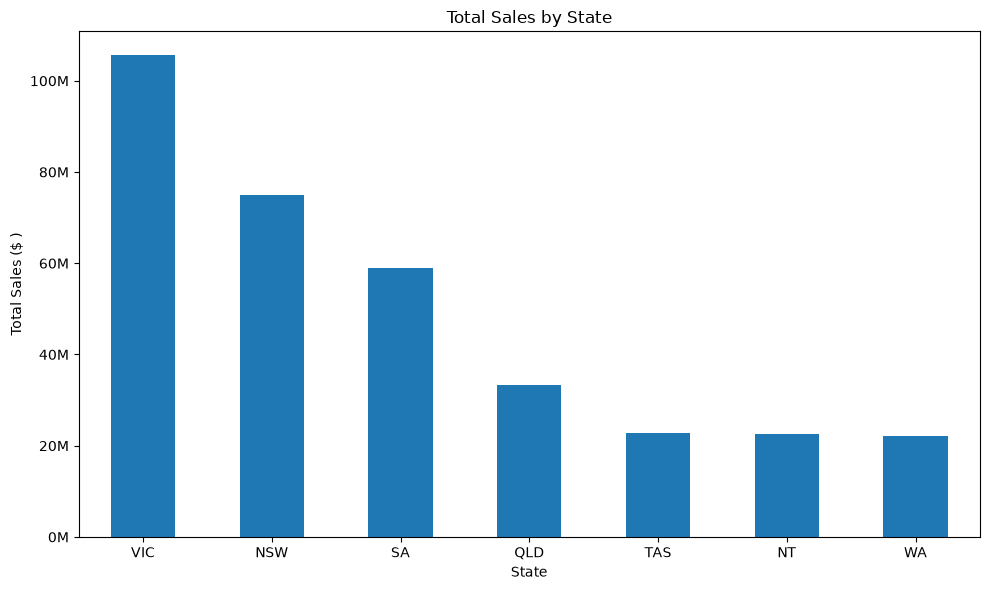

In [30]:
# Visualize total sales by state

plt.figure(figsize=(10, 6))

state_sales_sorted.plot(kind="bar")

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales ($ )")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### State-Wise Sales Analysis

The state-wise sales visualization shows substantial differences in sales performance across the Australian states represented in the dataset.

**Victoria (VIC)** generated the highest total sales at **$105.565 million**, followed by **New South Wales (NSW)** at **$74.970 million** and **South Australia (SA)** at **$58.858 million**.

**Western Australia (WA)** recorded the lowest total sales at **$22.153 million**. Tasmania (TAS) and the Northern Territory (NT) also recorded substantially lower sales than the three highest-performing states.

The visualization demonstrates that Victoria was the strongest-performing state during the fourth quarter of 2020.

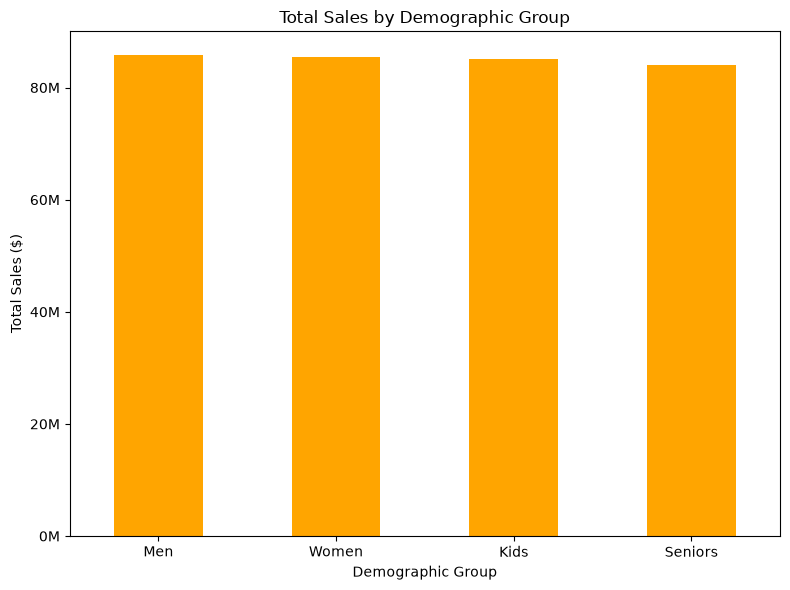

In [31]:
# Visualize total sales by demographic group

plt.figure(figsize=(8, 6))

group_sales_sorted.plot(kind="bar", color="orange")

plt.title("Total Sales by Demographic Group")
plt.xlabel("Demographic Group")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Group-Wise Sales Analysis

The group-wise sales visualization shows that total sales were relatively consistent across all four demographic groups.

**Men** generated the highest total sales at **$85.750 million**, followed closely by **Women** at **$85.443 million** and **Kids** at **$85.073 million**. **Seniors** generated the lowest total sales at **$84.038 million**.

Although Men recorded the highest sales and Seniors recorded the lowest, the differences between the demographic groups were relatively small. This suggests that sales were distributed fairly evenly across the four customer groups during the fourth quarter of 2020.

In [32]:
time_sales = df.groupby("Time")["Sales"].sum()

time_sales_sorted = time_sales.sort_values(ascending=False)

time_sales_sorted

Time
Morning      114207500
Afternoon    114007500
Evening      112087500
Name: Sales, dtype: int64

In [33]:
print("Time with the highest sales:", time_sales_sorted.idxmax())
print(f"Highest time sales amount: ${time_sales_sorted.max():,}")

print()

print(f"Time with the lowest sales: {time_sales_sorted.idxmin()}")
print(f"Lowest time sales amount: ${time_sales_sorted.min():,}")



Time with the highest sales: Morning
Highest time sales amount: $114,207,500

Time with the lowest sales: Evening
Lowest time sales amount: $112,087,500


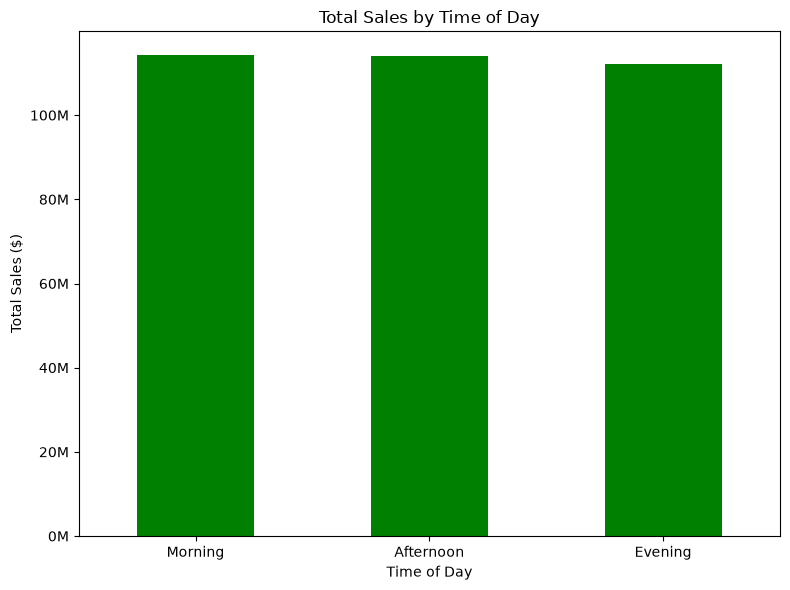

In [34]:
# Visualize sales by time of day

plt.figure(figsize=(8, 6))

time_sales_sorted.plot(kind="bar", color="green")

plt.title("Total Sales by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1_000_000:.0f}M")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Time-of-Day Sales Analysis

The time-of-day analysis shows that sales were relatively consistent throughout the day.

- **Morning** generated the highest total sales at **$114,207,500**.
- **Afternoon** generated **$114,007,500**.
- **Evening** generated the lowest total sales at **$112,087,500**.

Morning and afternoon sales were particularly similar, with only a small difference between the two periods. Although evening sales were slightly lower, the results do not indicate a major difference in sales performance based solely on time of day.

From a marketing perspective, morning and afternoon may provide slightly stronger opportunities for customer engagement. However, because sales were relatively balanced across all three periods, the data does not support concentrating marketing efforts exclusively on a single time of day.

## Sales Distribution Analysis

A distribution plot was created to examine the frequency and spread of individual sales values throughout the dataset.

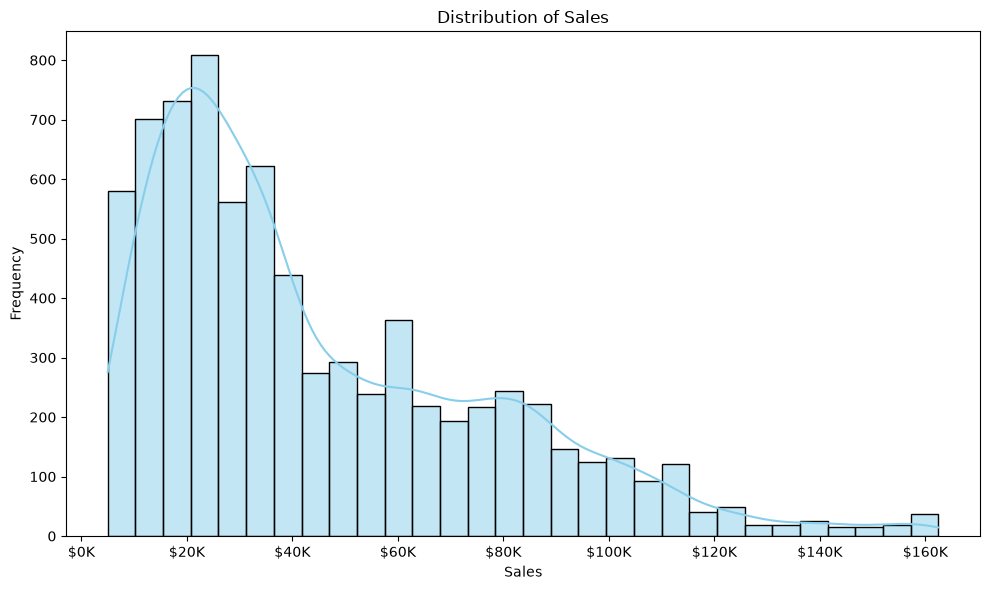

In [35]:
# Analyze sales distribution

plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="Sales",
    bins=30,
    kde=True,
    color="skyblue"
    )

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Sales Distribution Findings

The sales distribution is right-skewed (positively skewed), with a large concentration of observations at lower sales values and a progressively smaller number of observations at higher sales values.

The distribution helps explain why the **mean sales value of approximately $45,014** is higher than the **median sales value of $35,000**. Higher-value sales observations extend the right tail of the distribution and pull the mean upward.

The distribution therefore indicates that lower-to-moderate sales values occur more frequently, while very high sales values occur less frequently.

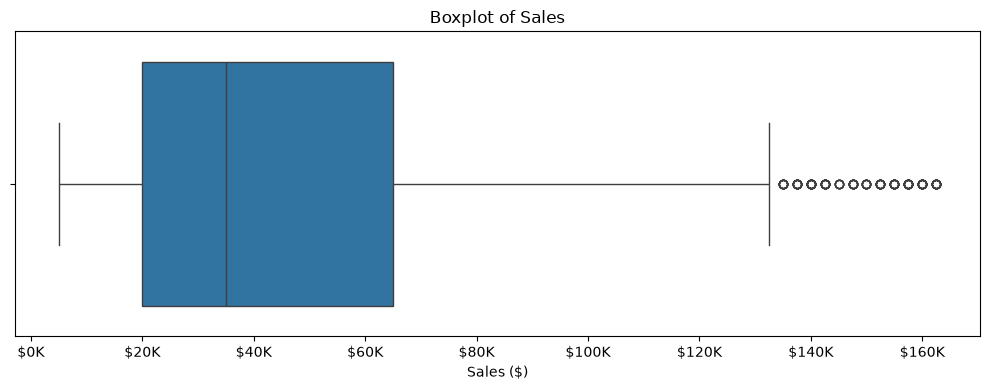

In [36]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Sales"
    )

plt.title("Boxplot of Sales")
plt.xlabel("Sales ($)")
plt.ylabel("")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000:.0f}K")
)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Box Plot Analysis

The box plot provides a visual summary of the distribution and spread of sales values.

The middle 50% of sales observations fall between approximately **$20,000 (Q1)** and **$65,000 (Q3)**, with a median sales value of **$35,000**.

Several high-value observations appear above the upper whisker and are identified as potential outliers by the box plot. These observations extend to a maximum sales value of **$162,500**. These values were retained because there is no evidence that they represent incorrect or invalid data.

The longer upper range and high-value observations further support the finding that the sales distribution is right-skewed.

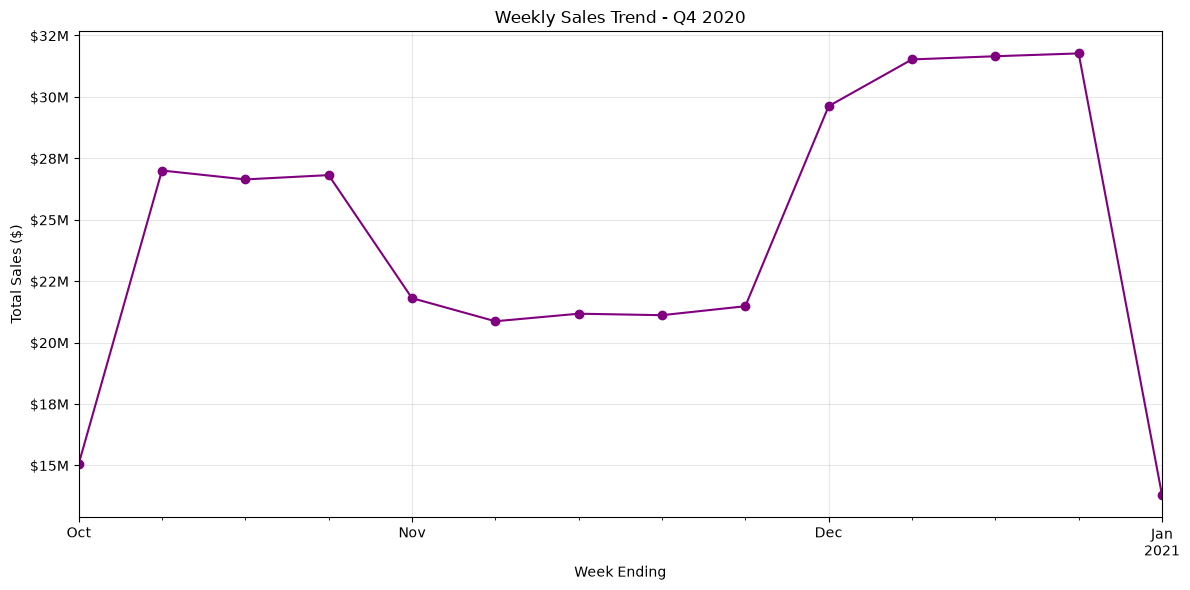

In [37]:
# Visualize weekly sales trends

plt.figure(figsize=(12, 6))

weekly_sales.plot(kind="line",
                  marker="o",
                  color="purple"
                  )

plt.title("Weekly Sales Trend - Q4 2020")
plt.xlabel("Week Ending")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.grid(True, alpha=0.3)  # Add grid lines with some transparency
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

### Weekly Sales Trend Analysis

The weekly sales trend shows noticeable changes in sales performance throughout the fourth quarter of 2020.

Sales remained relatively strong during most of October before declining during November. Weekly sales generally remained around $21 million during much of November.

A significant increase occurred beginning in late November and continued throughout December. Weekly sales exceeded approximately $29 million at the beginning of December and remained above $31 million during several weeks later in the month.

The first and final data points represent partial weeks because the dataset begins on October 1 and ends on December 31. Therefore, their lower sales totals should not be interpreted as full-week performance.

Overall, the weekly trend supports the monthly analysis, showing weaker sales performance during November followed by substantial growth during December.

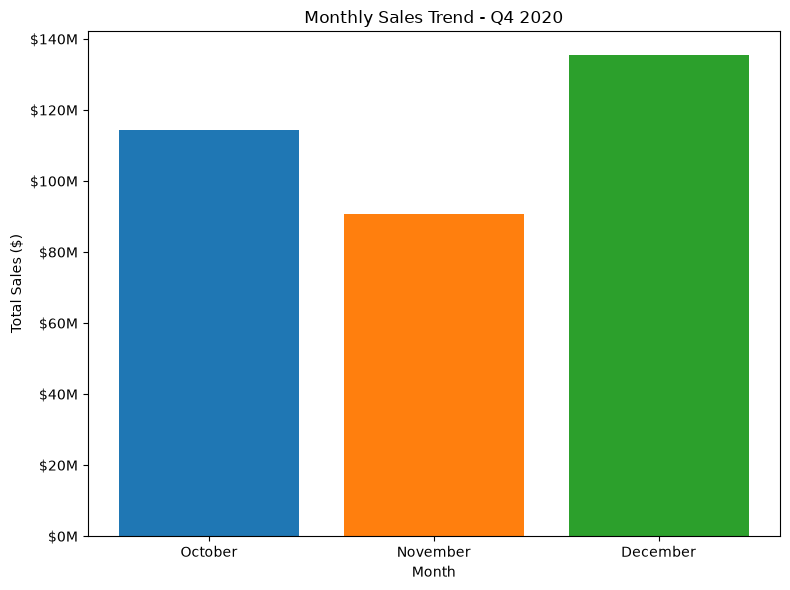

In [38]:
plt.figure(figsize=(8, 6))

plt.bar(
    ["October", "November", "December"],
    monthly_sales.to_list(),
    color=["#1f77b4", "#ff7f0e", "#2ca02c"]  # Different colors for each month
)

plt.title("Monthly Sales Trend - Q4 2020")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.tight_layout()
plt.show()

### Monthly Sales Trend Analysis

The monthly sales analysis shows a clear change in sales performance during the fourth quarter of 2020.

- **October** generated approximately **$114.29 million** in sales.
- **November** declined to approximately **$90.68 million**, making it the lowest-performing month of the quarter.
- **December** increased significantly to approximately **$135.33 million**, making it the strongest-performing month.

The results indicate a decline in sales during November followed by a strong recovery in December. This trend is consistent with the weekly sales analysis, which also showed stronger sales performance toward the end of the quarter.

In [44]:
state_group_sales = df.groupby(["State", "Group"])["Sales"].sum().unstack()

state_group_sales

Group,Kids,Men,Seniors,Women
State,,,,
NSW,18587500,19022500,18187500,19172500
NT,5700000,5762500,5465000,5652500
QLD,8510000,8392500,8190000,8325000
SA,14515000,14655000,14717500,14970000
TAS,5775000,5757500,5650000,5577500
VIC,26360000,26407500,26315000,26482500
WA,5625000,5752500,5512500,5262500


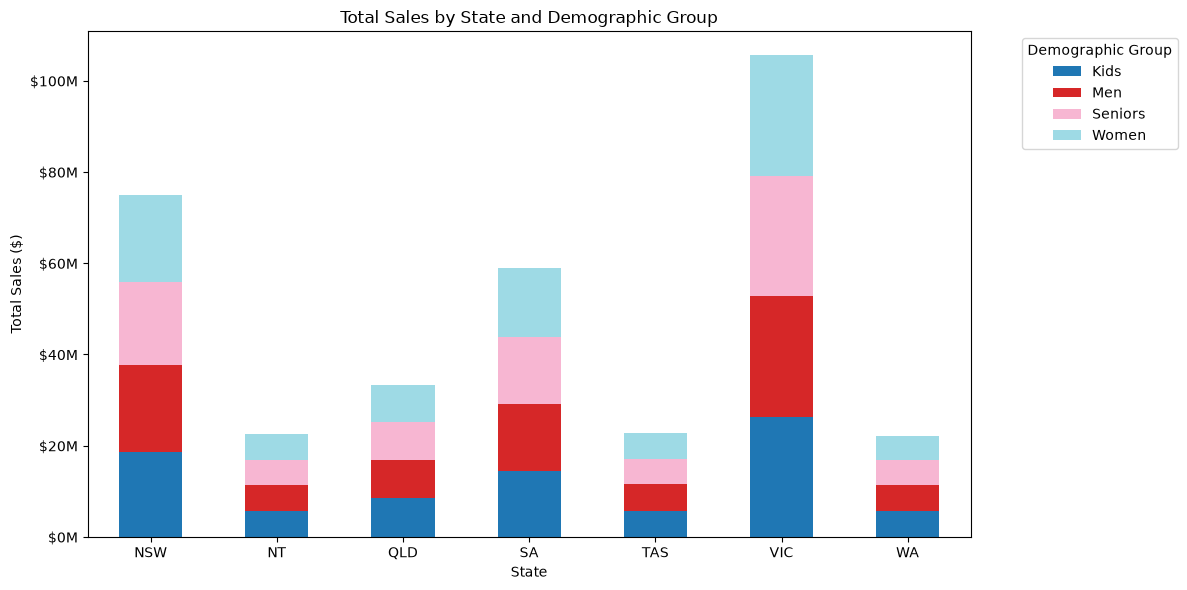

In [40]:
# Compare demographic sales contribution by state

state_group_sales.plot(
    kind="bar",
    figsize=(12, 6),
    stacked=True,
    colormap="tab20"
)

plt.title("Total Sales by State and Demographic Group")
plt.xlabel("State")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=0)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.0f}M")
)

plt.legend(title="Demographic Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

# Daily Sales and Peak/Off-peak Analysis

The following cells add a daily sales chart (line plot) and a concise peak/off-peak analysis by time-of-day. These visualizations use Seaborn for consistent styling and clear statistical plots.

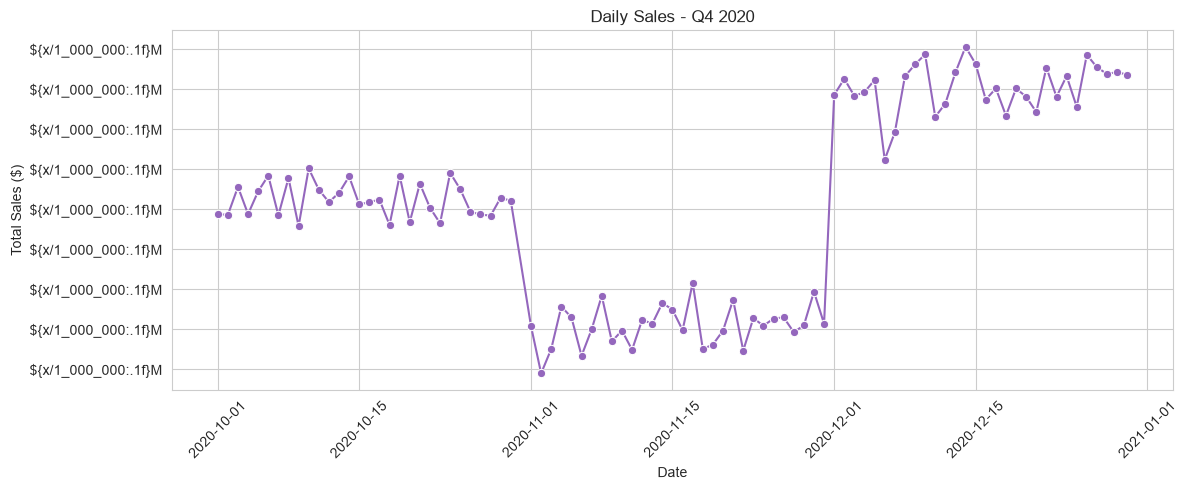

In [41]:
# Daily sales aggregation and line chart
daily_sales = df.groupby(df['Date'].dt.date)['Sales'].sum()
daily_sales.index = pd.to_datetime(daily_sales.index)

plt.figure(figsize=(12, 5))
sns.set_style('whitegrid')
sns.lineplot(x=daily_sales.index, y=daily_sales.values, marker='o', color='tab:purple')
plt.title('Daily Sales - Q4 2020')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${{x/1_000_000:.1f}}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Keep the daily_sales series available for downstream reporting
daily_sales = daily_sales

Time-of-day sales (total and % contribution):
               Sales        Pct
Time                           
Afternoon  114007500  33.501811
Evening    112087500  32.937607
Morning    114207500  33.560582

Peak period: Morning (114,207,500 | 33.6%)
Off-peak period: Evening (112,087,500 | 32.9%)


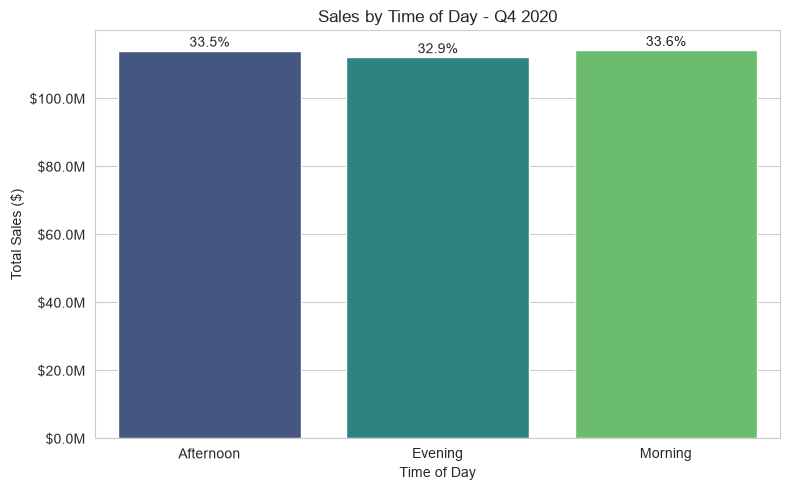

In [52]:
# Peak / Off-peak analysis using existing time-of-day grouping

# Percent contribution by period
time_sales_pct = (time_sales / time_sales.sum()) * 100

print("Time-of-day sales (total and % contribution):")
print(
    pd.concat(
        [time_sales, time_sales_pct.rename("Pct")],
        axis=1
    )
)

peak = time_sales.idxmax()
offpeak = time_sales.idxmin()

print()
print(
    f"Peak period: {peak} "
    f"({time_sales[peak]:,} | {time_sales_pct[peak]:.1f}%)"
)

print(
    f"Off-peak period: {offpeak} "
    f"({time_sales[offpeak]:,} | {time_sales_pct[offpeak]:.1f}%)"
)

# Visualize with Seaborn barplot and annotate percentages
plt.figure(figsize=(8, 5))

sns.barplot(
    x=time_sales.index,
    y=time_sales.values,
    hue=time_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Sales by Time of Day - Q4 2020")
plt.xlabel("Time of Day")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

for i, v in enumerate(time_sales.values):
    pct = time_sales_pct.iloc[i]

    plt.text(
        i,
        v + max(time_sales.values) * 0.01,
        f"{pct:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

# 10. Business Insights and Recommendations

# Business Insights and Recommendations

## Key Findings

### Regional Performance

Victoria (VIC) generated the highest total sales during Q4 2020 with approximately **$105.6 million**, making it the strongest-performing state. Western Australia (WA) recorded the lowest total sales at approximately **$22.2 million**.

The state analysis indicates that geographic location had a larger impact on total sales performance than demographic group differences.

### Customer Demographic Performance

Sales performance was relatively consistent across all customer groups. The Men demographic generated the highest sales at approximately **$85.75 million**, while Seniors generated the lowest at approximately **$84.04 million**.

The small difference between groups suggests that products appealed broadly across customer segments rather than being concentrated within a single demographic.

### Time-Based Trends

December was the strongest month of Q4 2020, generating approximately **$135.3 million** in sales. November was the weakest month with approximately **$90.7 million**.

Weekly trends showed increased sales activity throughout December, suggesting stronger customer purchasing activity toward the end of the quarter.

### Marketing Recommendations

Based on the analysis:

- Marketing efforts should prioritize high-performing regions such as Victoria while investigating opportunities to improve sales in lower-performing states.
- Since demographic groups performed similarly, marketing campaigns should continue targeting all customer segments rather than focusing on only one group.
- Increased promotional activity during periods similar to December may help maximize sales performance.
- Morning and afternoon periods showed slightly higher sales than evening periods, but differences were small. Marketing campaigns should remain distributed throughout the day rather than focusing exclusively on one time period.

### Data Distribution Findings

The sales distribution was right-skewed, with most sales occurring in lower-to-middle ranges and fewer high-value transactions extending the upper range.

The presence of higher-value sales contributed to the mean being higher than the median, indicating that larger transactions influenced overall sales performance.